In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    "trip_id": range(1, n+1),
    "pickup_time": pd.date_range(start="2024-01-01", periods=n, freq="h"),
    "trip_duration_min": np.random.randint(5, 60, n),
    "pickup_location": np.random.choice(["Downtown", "Airport", "Suburb", "Mall"], n),
    "drop_location": np.random.choice(["Downtown", "Airport", "Suburb", "Mall"], n),
    "driver_id": np.random.randint(100, 200, n),
    "distance_km": np.round(np.random.uniform(1, 20, n), 2),
})

df["fare_amount"] = np.round(50 + df["distance_km"] * 10 + df["trip_duration_min"] * 2, 2)

df.to_csv("ride_sharing_data.csv", index=False)

df.head()

,trip_id,pickup_time,trip_duration_min,pickup_location,drop_location,driver_id,distance_km,fare_amount
0,1,2024-01-01 00:00:00,43,Airport,Downtown,135,15.99,295.9
1,2,2024-01-01 01:00:00,56,Downtown,Airport,196,11.89,280.9
2,3,2024-01-01 02:00:00,33,Airport,Suburb,135,13.52,251.2
3,4,2024-01-01 03:00:00,19,Suburb,Mall,102,5.79,145.9
4,5,2024-01-01 04:00:00,47,Suburb,Airport,172,5.18,195.8


In [4]:
# Convert pickup_time to datetime
df['pickup_time'] = pd.to_datetime(df['pickup_time'])

# Create new features
df['hour'] = df['pickup_time'].dt.hour
df['day'] = df['pickup_time'].dt.day_name()

df.head()

,trip_id,pickup_time,trip_duration_min,pickup_location,drop_location,driver_id,distance_km,fare_amount,hour,day
0,1,2024-01-01 00:00:00,43,Airport,Downtown,135,15.99,295.9,0,Monday
1,2,2024-01-01 01:00:00,56,Downtown,Airport,196,11.89,280.9,1,Monday
2,3,2024-01-01 02:00:00,33,Airport,Suburb,135,13.52,251.2,2,Monday
3,4,2024-01-01 03:00:00,19,Suburb,Mall,102,5.79,145.9,3,Monday
4,5,2024-01-01 04:00:00,47,Suburb,Airport,172,5.18,195.8,4,Monday


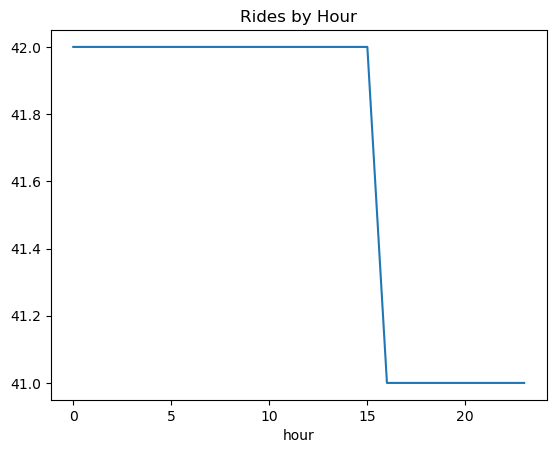

In [5]:
# EDA 
# Peak Hours
df.groupby('hour').size().plot(kind='line', title='Rides by Hour')
plt.show()

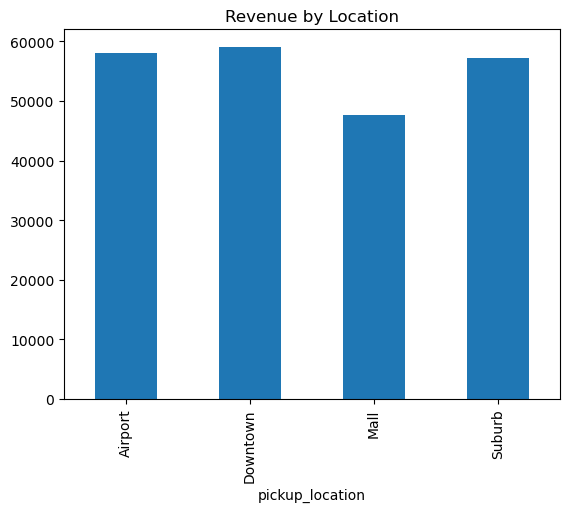

In [6]:
# Revenue by Location
df.groupby('pickup_location')['fare_amount'].sum().plot(kind='bar', title='Revenue by Location')
plt.show()

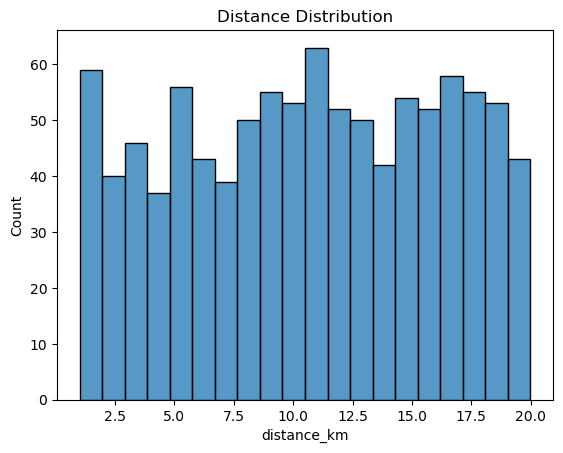

In [7]:
# Ride Distance Distribution 
sns.histplot(df['distance_km'], bins=20)
plt.title("Distance Distribution")
plt.show()

In [8]:
# Key Metrics
total_revenue = df['fare_amount'].sum()
avg_fare = df['fare_amount'].mean()
total_rides = len(df)

print("Total Revenue:", total_revenue)
print("Average Fare:", avg_fare)
print("Total Rides:", total_rides)

Total Revenue: 221899.7
Average Fare: 221.89970000000002
Total Rides: 1000


In [9]:
# Machine Learning (Fare Prediction)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['distance_km', 'trip_duration_min']]
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Score:", model.score(X_test, y_test))

Model Score: 1.0


In [10]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
